# Prep for AGU abstract

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import xclimate as xclim

In [ ]:
FPPE_QBIN_ROOT = Path("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/qbin")
FPPE_QBIN_CASE = "EFLX_LH_TOT_month_1.none.binned_by.TLAI_month_1_x_AI_clim_1.15_x_15.pooled.AI_inv.199501-201412"

fppe_bs = xr.open_dataset(FPPE_QBIN_ROOT / FPPE_QBIN_CASE / f"{FPPE_QBIN_CASE}.nc")["EFLX_LH_TOT"]
fppe_bs_frac_cnt = fppe_bs.sel(stats="count") / fppe_bs.sel(stats="count").sum(dim=["x_bin", "y_bin"]) * 100
fppe_bs_frac_mem = (fppe_bs_frac_cnt>0).sum(dim="member") / len(fppe_bs_frac_cnt.member)

CMIP_QBIN_ROOT = Path("/glade/work/bbuchovecky/et_unc/proc/cmip6/cmip6/qbin")
CMIP_QBIN_PATTERN = "cmip6.*.evspsbl.qbin_pooled.199501-201412.*.nc"

cmip_bs_list = []
source_id = []
for f in sorted(CMIP_QBIN_ROOT.glob(CMIP_QBIN_PATTERN)):
    keys = f.stem.split(".")
    sid = keys[1]
    cmip_bs_list.append(xr.open_mfdataset(f)["evspsbl"])
    source_id.append(sid)

cmip_bs = xr.concat(cmip_bs_list, dim="source_id").assign_coords(source_id=source_id)
cmip_bs_frac_cnt = cmip_bs.sel(stats="count") / cmip_bs.sel(stats="count").sum(dim=["x_bin", "y_bin"]) * 100
cmip_bs_frac_sid = (cmip_bs_frac_cnt>0).sum(dim="source_id") / len(cmip_bs_frac_cnt.source_id)

Text(0.5, 0, 'Quantile bin edge')

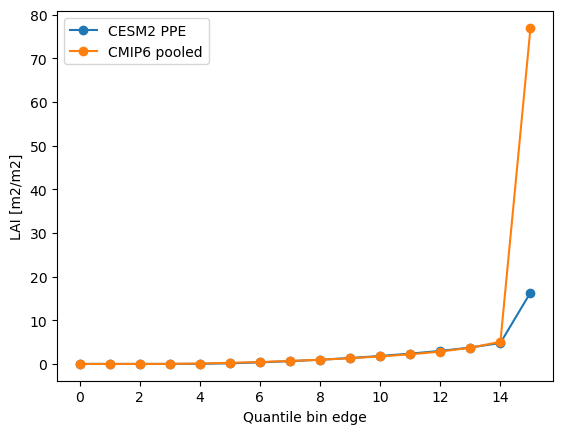

In [157]:
plt.plot(np.arange(16), fppe_bs.attrs["y_bin_edges"], marker="o", label="CESM2 PPE")
plt.plot(np.arange(16), cmip_bs.attrs["y_bin_edges"], marker="o", label="CMIP6 pooled")
plt.legend()
plt.ylabel("LAI [m2/m2]")
plt.xlabel("Quantile bin edge")

Text(0.5, 0, 'Quantile bin edge')

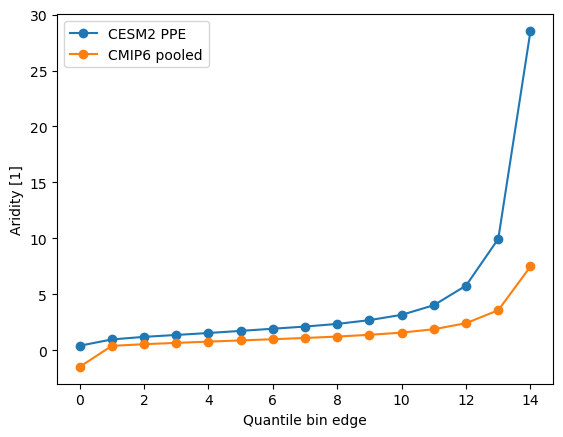

In [136]:
plt.plot(np.arange(16)[:-1], fppe_bs.attrs["x_bin_edges"][:-1], marker="o", label="CESM2 PPE")
plt.plot(np.arange(16)[:-1], cmip_bs.attrs["x_bin_edges"][:-1], marker="o", label="CMIP6 pooled")
plt.legend()
plt.ylabel("Aridity [1]")
plt.xlabel("Quantile bin edge")

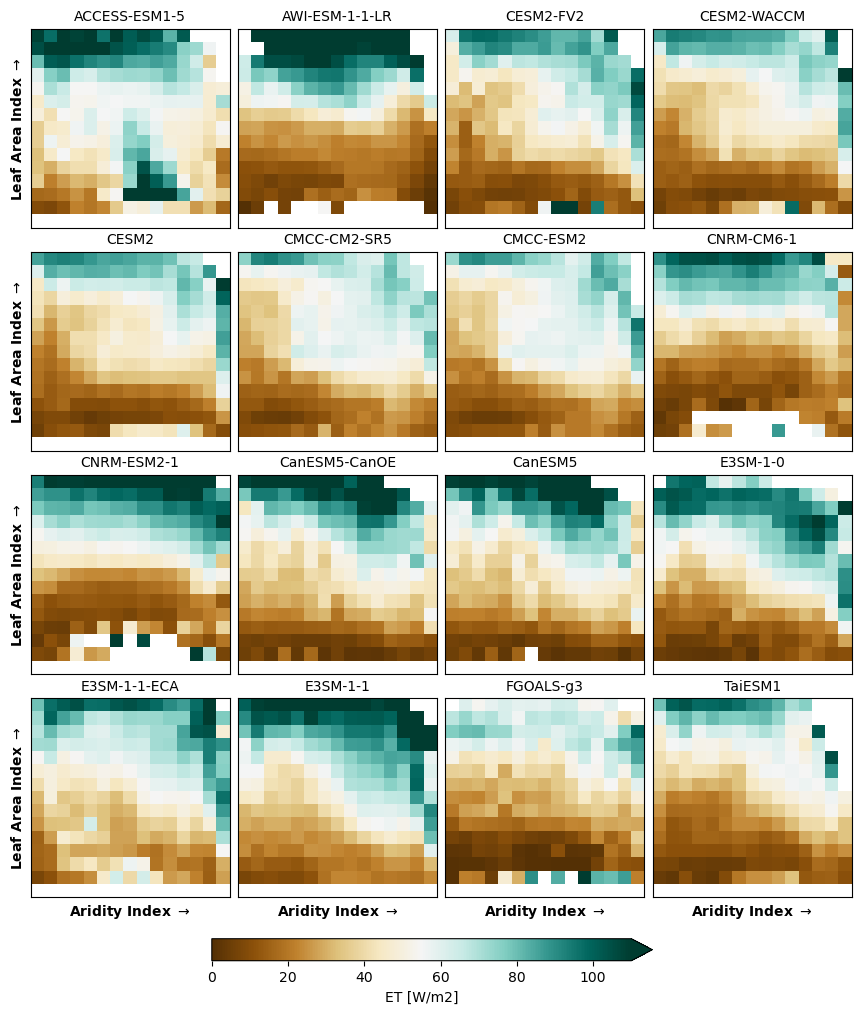

In [143]:
subplot_kwargs = dict(
    vmin=0,
    vmax=110,
    cmap="BrBG",
    add_colorbar=False,
    add_labels=False,
)

fig, axes = plt.subplots(4, 4, figsize=(8.5, 10), sharex=True, sharey=True, subplot_kw=dict(box_aspect=1), layout="constrained")
axs = axes.ravel()

im = None
for i, sid in enumerate(cmip_bs.source_id):
    im = cmip_bs.where(cmip_bs_frac_cnt>0).sel(source_id=sid, stats="mean").plot(ax=axs[i], **subplot_kwargs)
    axs[i].set_title(sid.item(), fontsize=10)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

for i in range(4):
    axes[-1, i].set_xlabel("Aridity Index $\\rightarrow$", fontweight="bold")
    axes[i, 0].set_ylabel("Leaf Area Index $\\rightarrow$", fontweight="bold")

cb = fig.colorbar(im, ax=axs, extend="max", orientation="horizontal", fraction=0.025, pad=0.02)
cb.set_label("ET [W/m2]")

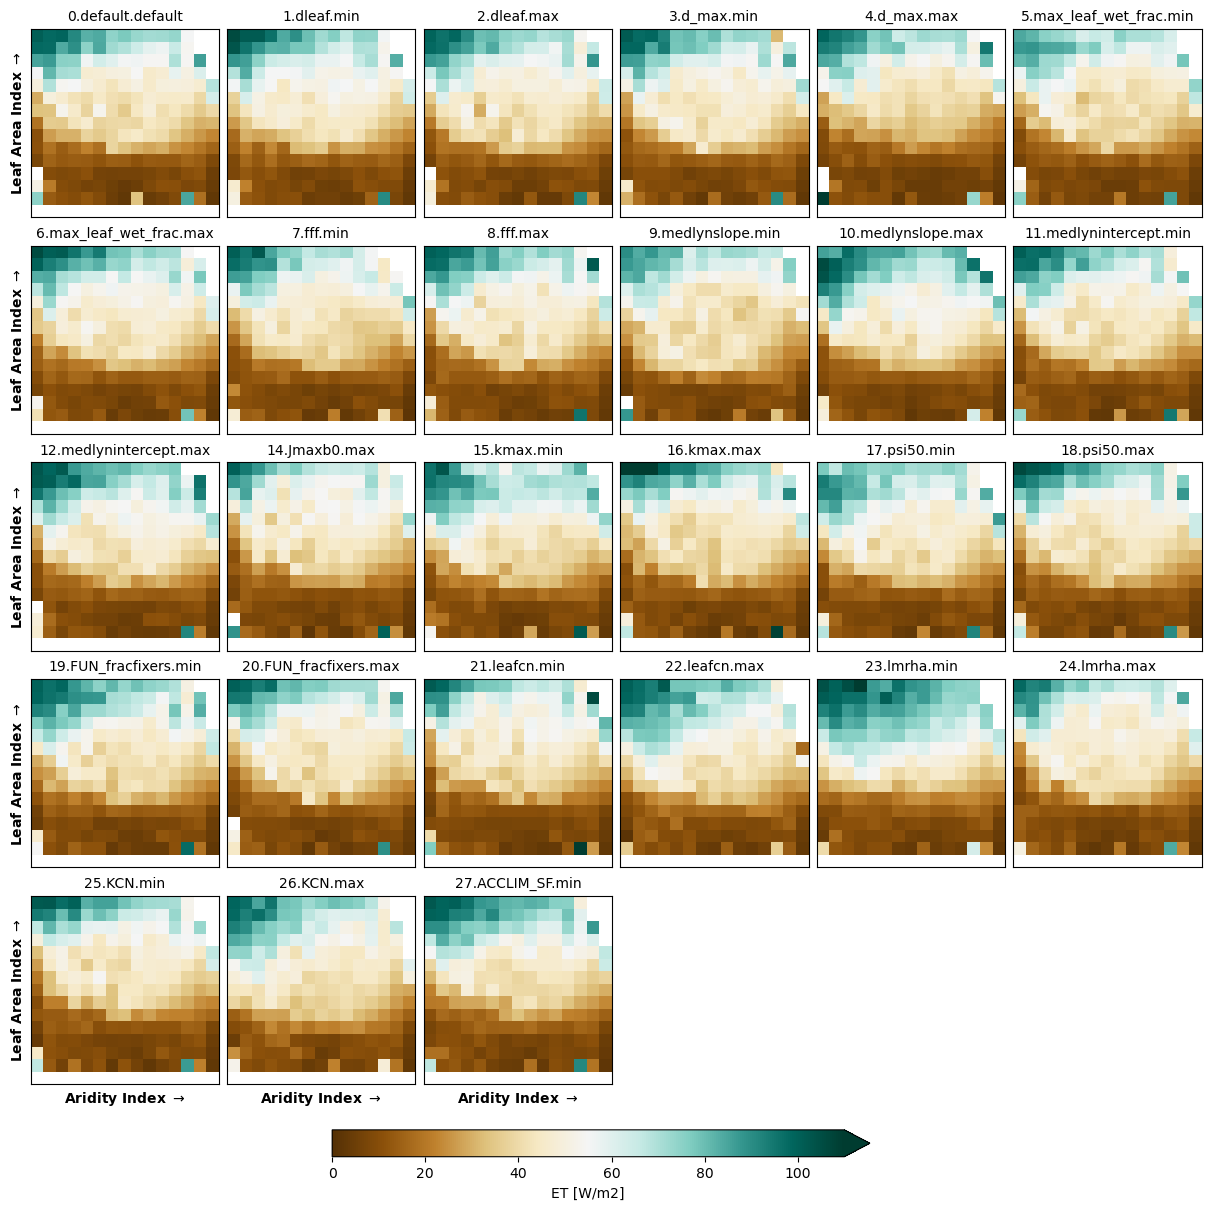

In [51]:
subplot_kwargs = dict(
    vmin=0,
    vmax=110,
    cmap="BrBG",
    add_colorbar=False,
    add_labels=False,
)

fig, axes = plt.subplots(5, 6, figsize=(12, 12), sharex=True, sharey=True, subplot_kw=dict(box_aspect=1), layout="constrained")
axs = axes.ravel()

im = None
for i, mem in enumerate(fppe_bs.member):
    im = fppe_bs.where(fppe_bs_frac_cnt>0).sel(member=mem, stats="mean").plot(ax=axs[i], **subplot_kwargs)
    axs[i].set_title(xclim.ppe.get_member_name(mem.item()), fontsize=10)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

for i in range(6):
    axes[-1, i].set_xlabel("Aridity Index $\\rightarrow$", fontweight="bold")

for i in range(5):
    axes[i, 0].set_ylabel("Leaf Area Index $\\rightarrow$", fontweight="bold")

cb = fig.colorbar(im, ax=axs, extend="max", orientation="horizontal", fraction=0.025, pad=0.02)
cb.set_label("ET [W/m2]")

for ax in axs[-3:]:
    ax.remove()

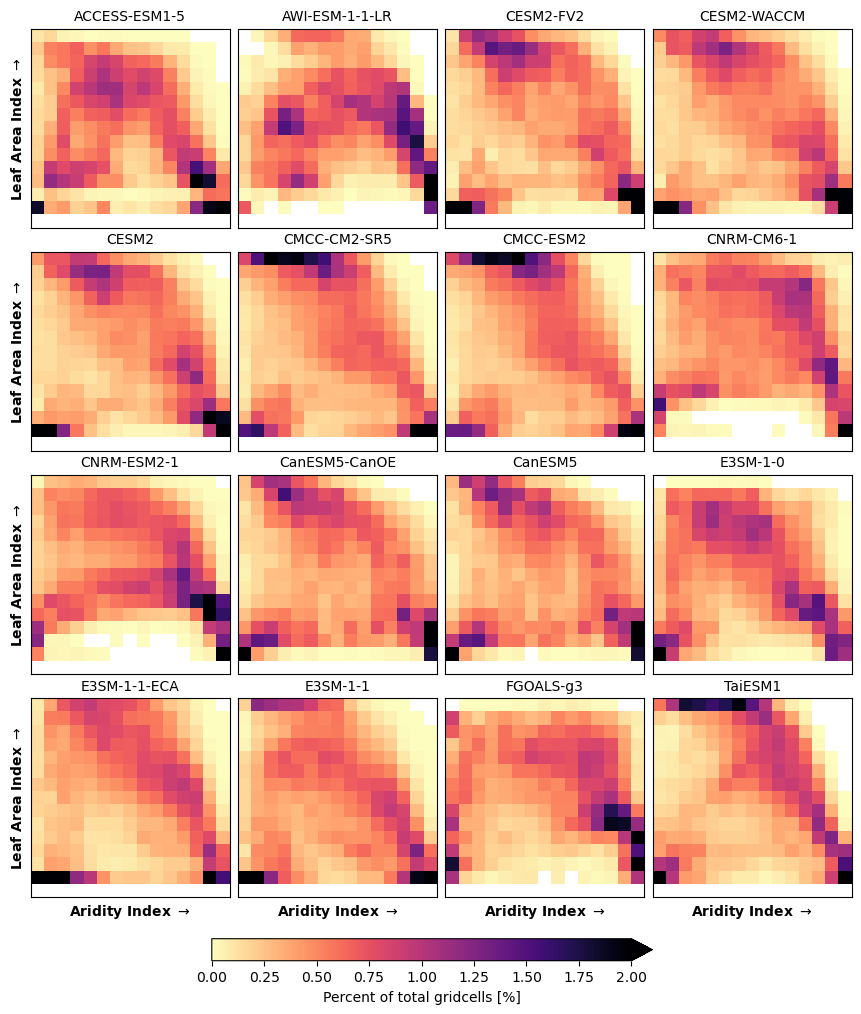

In [153]:
subplot_kwargs = dict(
    vmin=0,
    vmax=2,
    robust=True,
    cmap="magma_r",
    add_colorbar=False,
    add_labels=False,
)

fig, axes = plt.subplots(4, 4, figsize=(8.5, 10), sharex=True, sharey=True, subplot_kw=dict(box_aspect=1), layout="constrained")
axs = axes.ravel()

im = None
for i, sid in enumerate(cmip_bs.source_id):
    im = cmip_bs_frac_cnt.where(cmip_bs_frac_cnt>0).sel(source_id=sid).plot(ax=axs[i], **subplot_kwargs)
    axs[i].set_title(sid.item(), fontsize=10)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

for i in range(4):
    axes[-1, i].set_xlabel("Aridity Index $\\rightarrow$", fontweight="bold")
    axes[i, 0].set_ylabel("Leaf Area Index $\\rightarrow$", fontweight="bold")

cb = fig.colorbar(im, ax=axs, extend="max", orientation="horizontal", fraction=0.025, pad=0.02)
cb.set_label("Percent of total gridcells [%]")

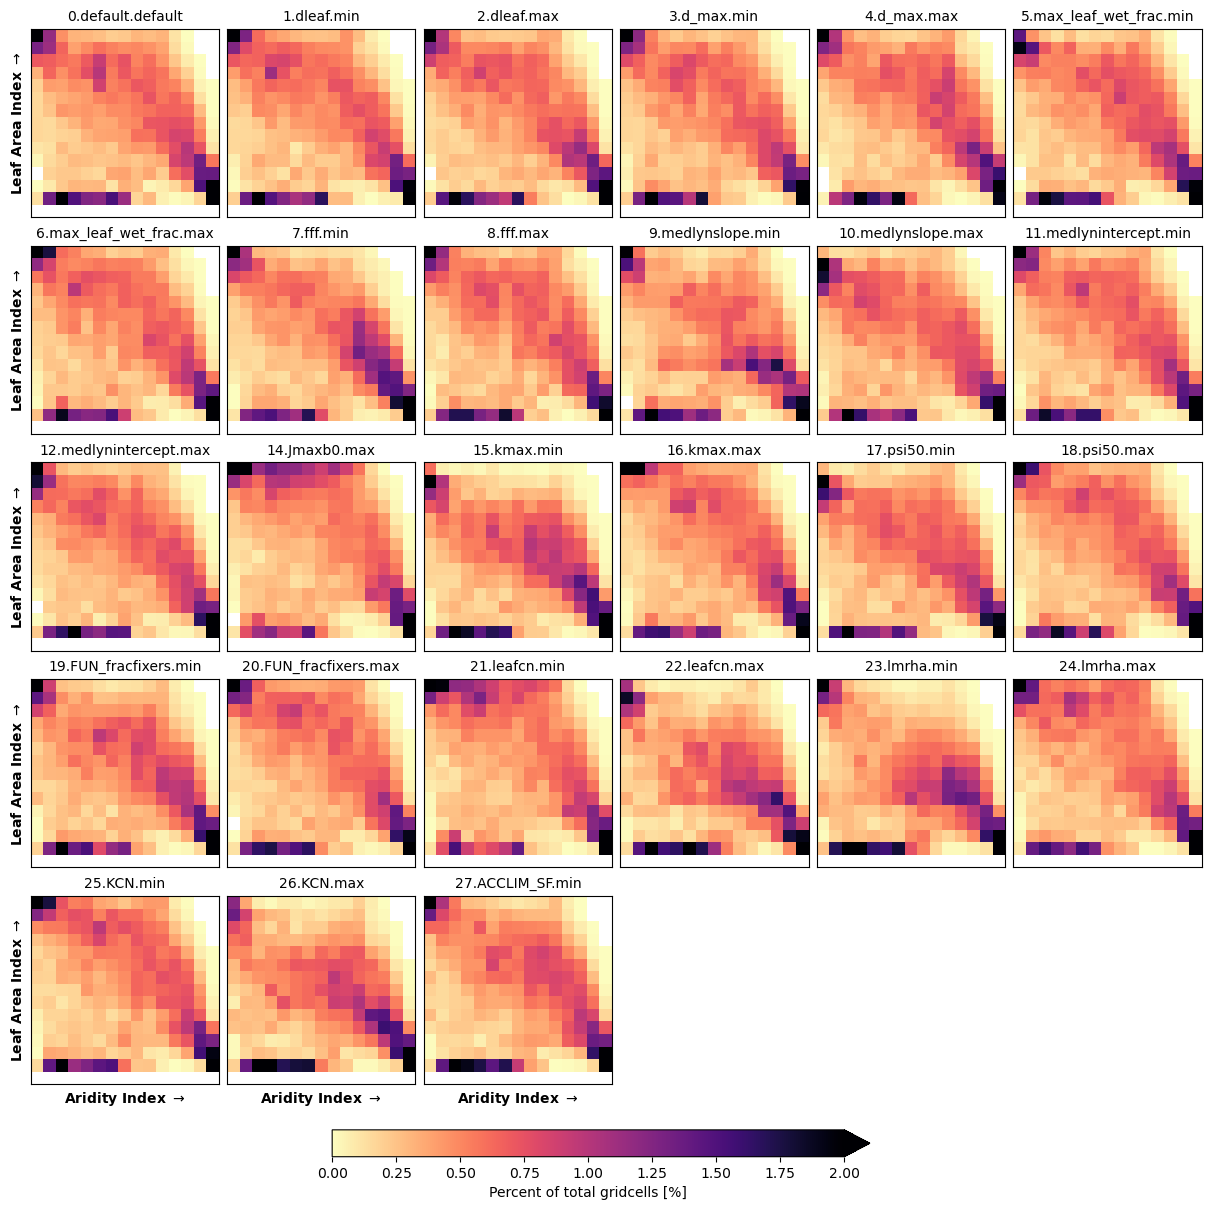

In [156]:
subplot_kwargs = dict(
    vmin=0,
    vmax=2,
    robust=True,
    cmap="magma_r",
    add_colorbar=False,
    add_labels=False,
)

fig, axes = plt.subplots(5, 6, figsize=(12, 12), sharex=True, sharey=True, subplot_kw=dict(box_aspect=1), layout="constrained")
axs = axes.ravel()

im = None
for i, mem in enumerate(fppe_bs.member):
    im = fppe_bs_frac_cnt.where(fppe_bs_frac_cnt>0).sel(member=mem).plot(ax=axs[i], **subplot_kwargs)
    axs[i].set_title(xclim.ppe.get_member_name(mem.item()), fontsize=10)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

for i in range(6):
    axes[-1, i].set_xlabel("Aridity Index $\\rightarrow$", fontweight="bold")

for i in range(5):
    axes[i, 0].set_ylabel("Leaf Area Index $\\rightarrow$", fontweight="bold")

cb = fig.colorbar(im, ax=axs, extend="max", orientation="horizontal", fraction=0.025, pad=0.02)
cb.set_label("Percent of total gridcells [%]")

for ax in axs[-3:]:
    ax.remove()

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


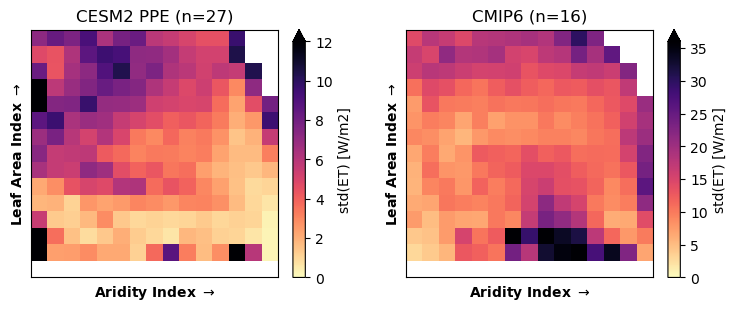

In [88]:
fig, axs = plt.subplots(1, 2, figsize=(7.5, 3), subplot_kw=dict(box_aspect=1), layout="constrained")
fppe_bs.sel(stats="mean").where(fppe_bs_frac_mem>0.75).std(dim="member").plot(ax=axs[0], vmin=0, vmax=12, cmap="magma_r", cbar_kwargs={"label": "std(ET) [W/m2]"})
cmip_bs.sel(stats="mean").where(cmip_bs_frac_sid>0.75).std(dim="source_id").plot(ax=axs[1], vmin=0, vmax=36, cmap="magma_r", cbar_kwargs={"label": "std(ET) [W/m2]"})
axs[0].set_title(f"CESM2 PPE (n={len(fppe_bs.member)})")
axs[1].set_title(f"CMIP6 (n={len(cmip_bs.source_id)})")
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("Aridity Index $\\rightarrow$", fontweight="bold")
    ax.set_ylabel("Leaf Area Index $\\rightarrow$", fontweight="bold")

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


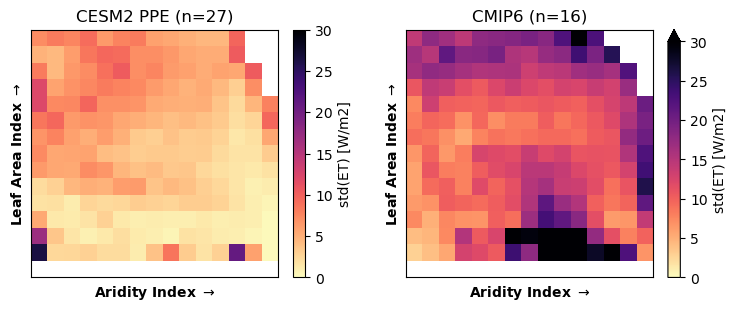

In [141]:
fig, axs = plt.subplots(1, 2, figsize=(7.5, 3), subplot_kw=dict(box_aspect=1), layout="constrained")
fppe_bs.sel(stats="mean").where(fppe_bs_frac_mem>0.75).std(dim="member").plot(ax=axs[0], vmin=0, vmax=30, cmap="magma_r", cbar_kwargs={"label": "std(ET) [W/m2]"})
cmip_bs.sel(stats="mean").where(cmip_bs_frac_sid>0.75).std(dim="source_id").plot(ax=axs[1], vmin=0, vmax=30, cmap="magma_r", cbar_kwargs={"label": "std(ET) [W/m2]"})
axs[0].set_title(f"CESM2 PPE (n={len(fppe_bs.member)})")
axs[1].set_title(f"CMIP6 (n={len(cmip_bs.source_id)})")
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("Aridity Index $\\rightarrow$", fontweight="bold")
    ax.set_ylabel("Leaf Area Index $\\rightarrow$", fontweight="bold")

/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


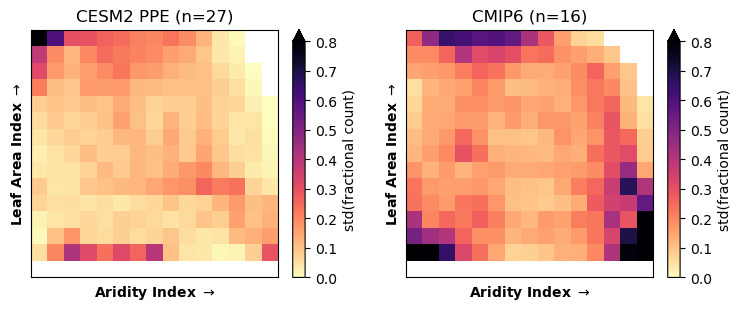

In [112]:
fig, axs = plt.subplots(1, 2, figsize=(7.5, 3), subplot_kw=dict(box_aspect=1), layout="constrained")
fppe_bs_frac_cnt.where(fppe_bs_frac_mem>0.75).std(dim="member").plot(ax=axs[0], vmin=0, vmax=0.8, robust=True, cmap="magma_r", cbar_kwargs={"label": "std(fractional count)"})
cmip_bs_frac_cnt.where(cmip_bs_frac_sid>0.75).std(dim="source_id").plot(ax=axs[1], vmin=0, vmax=0.8, robust=True, cmap="magma_r", cbar_kwargs={"label": "std(fractional count)"})
axs[0].set_title(f"CESM2 PPE (n={len(fppe_bs.member)})")
axs[1].set_title(f"CMIP6 (n={len(cmip_bs.source_id)})")
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("Aridity Index $\\rightarrow$", fontweight="bold")
    ax.set_ylabel("Leaf Area Index $\\rightarrow$", fontweight="bold")

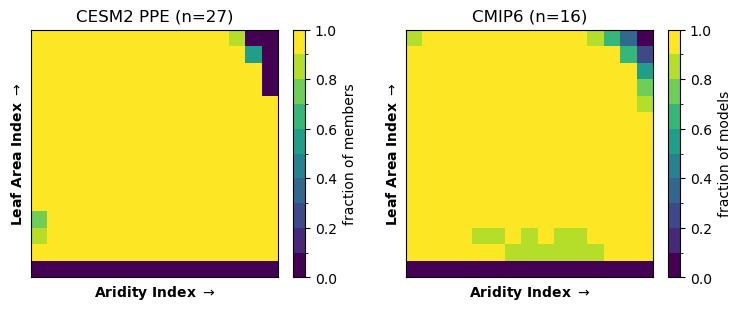

In [106]:
fig, axs = plt.subplots(1, 2, figsize=(7.5, 3), subplot_kw=dict(box_aspect=1), layout="constrained")
fppe_bs_frac_mem.plot(ax=axs[0], levels=np.linspace(0, 1+1e-6, 11), cbar_kwargs={"label": "fraction of members"})
cmip_bs_frac_sid.plot(ax=axs[1], levels=np.linspace(0, 1+1e-6, 11), cbar_kwargs={"label": "fraction of models"})
axs[0].set_title(f"CESM2 PPE (n={len(fppe_bs.member)})")
axs[1].set_title(f"CMIP6 (n={len(cmip_bs.source_id)})")
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("Aridity Index $\\rightarrow$", fontweight="bold")
    ax.set_ylabel("Leaf Area Index $\\rightarrow$", fontweight="bold")

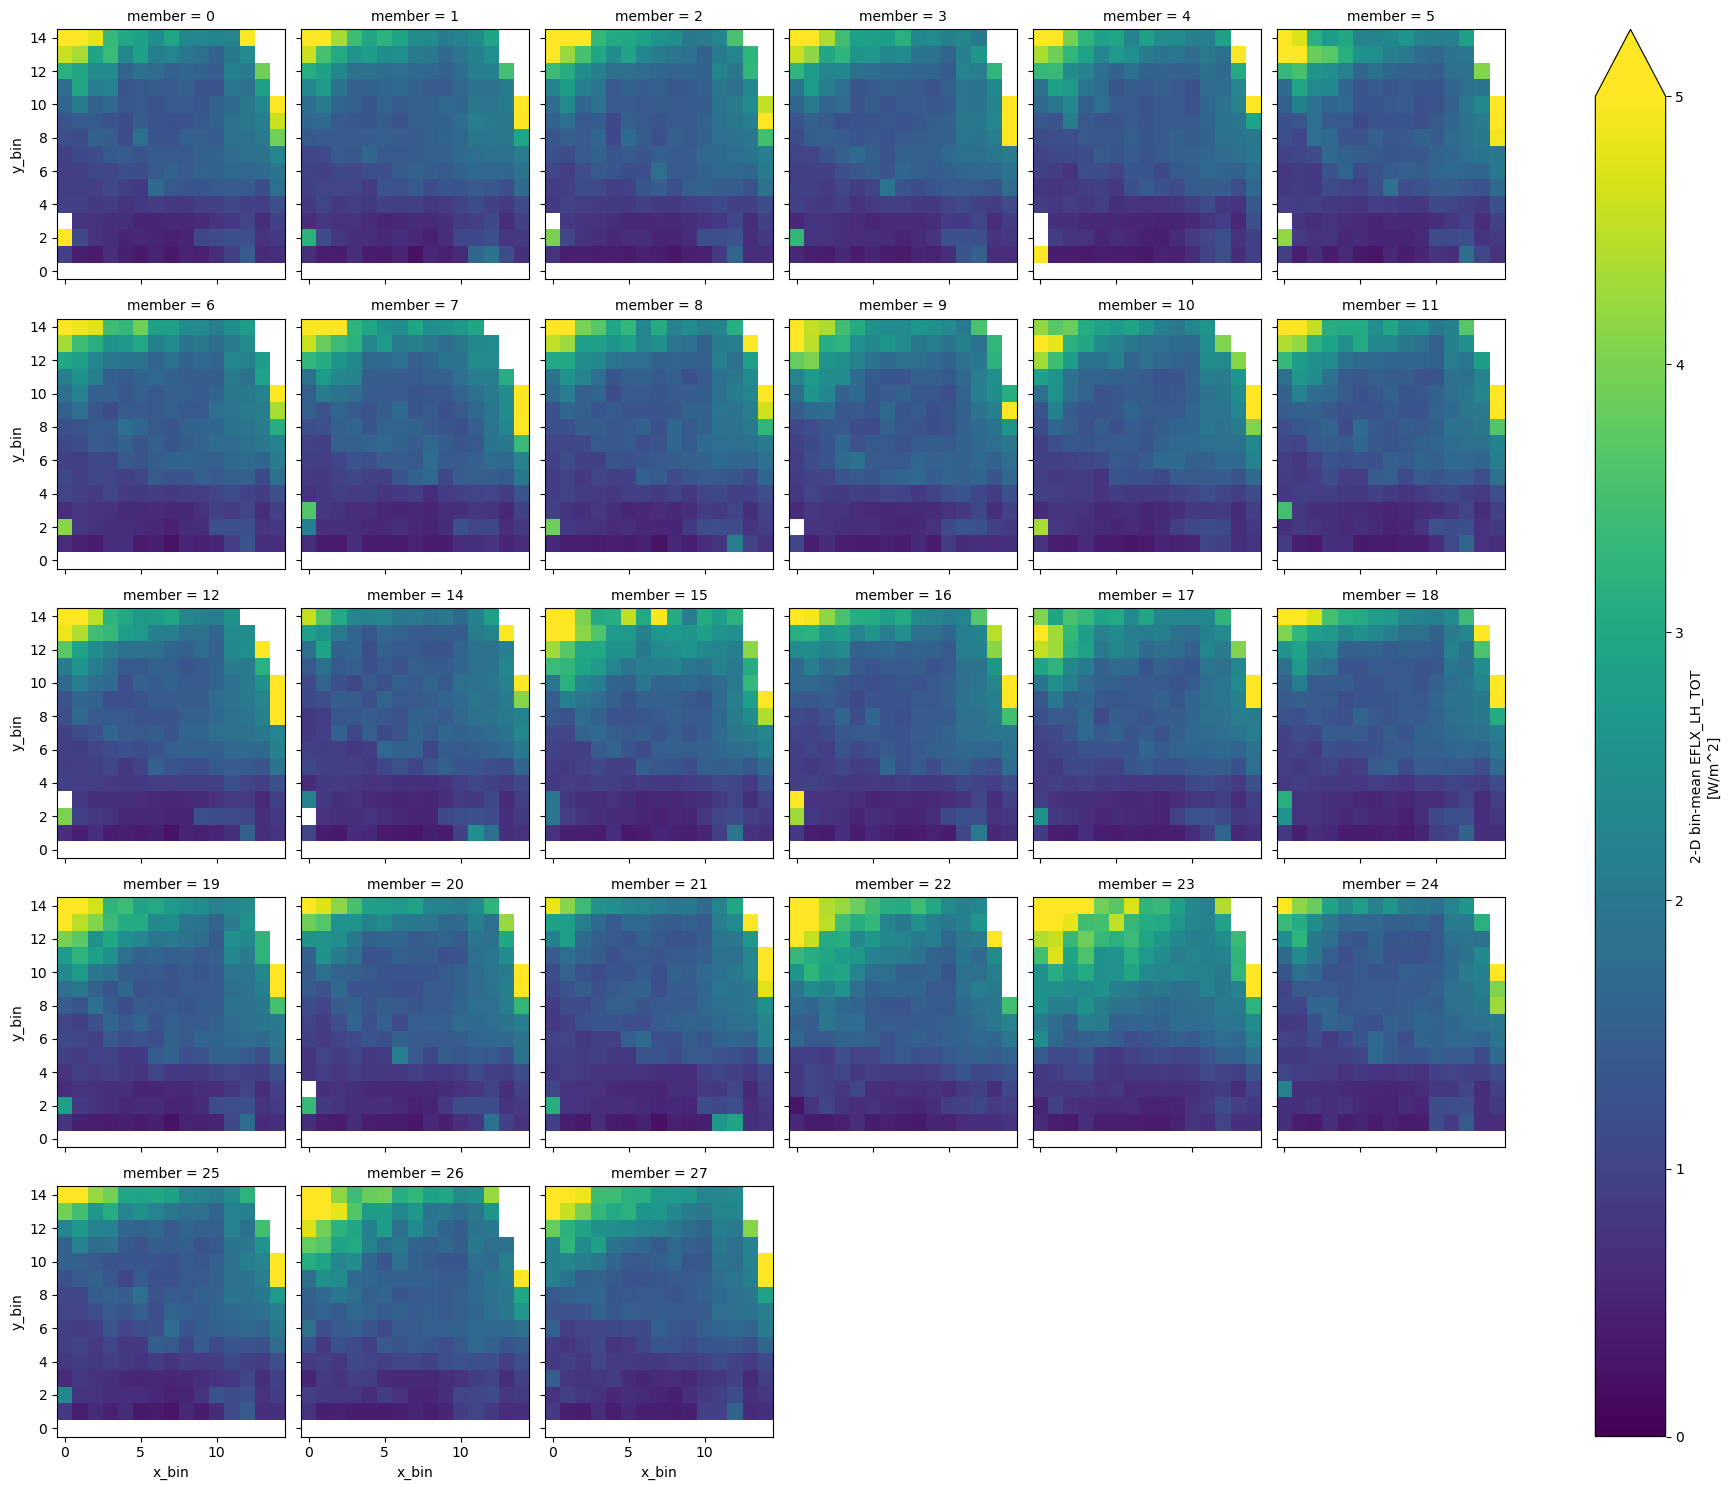

In [ ]:
(fppe_bs.sel(stats="mean") / np.sqrt(fppe_bs.sel(stats="var_samp"))).plot(col="member", col_wrap=6, vmin=0, vmax=5)

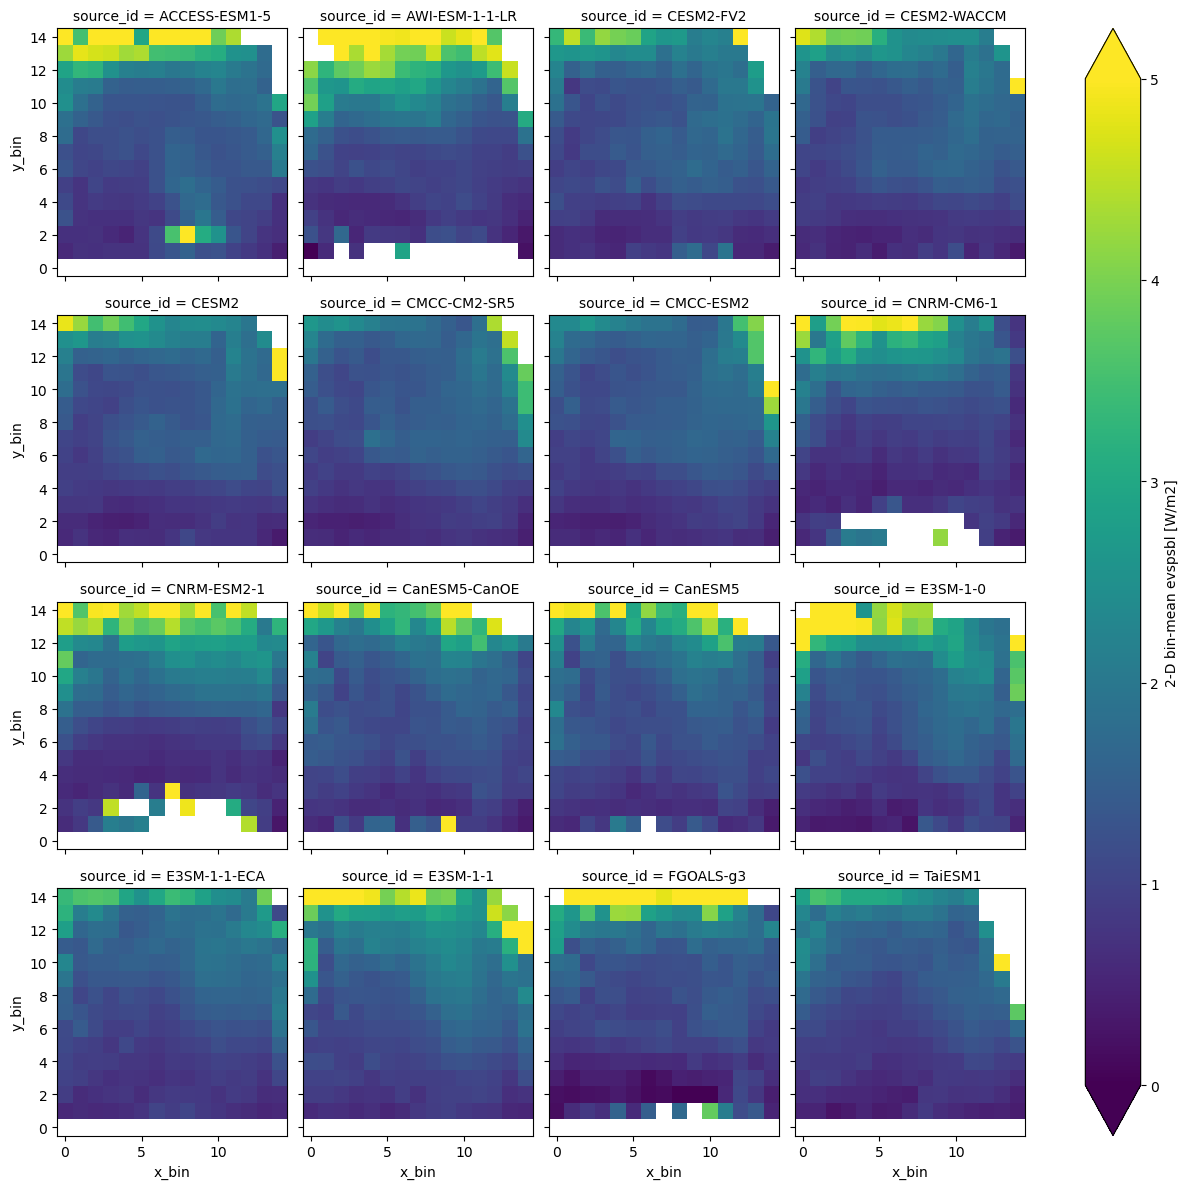

In [ ]:
(cmip_bs.sel(stats="mean") / np.sqrt(cmip_bs.sel(stats="var_samp"))).plot(col="source_id", col_wrap=4, vmin=0, vmax=5)